In [44]:
import pandas as pd
import geopandas as gpd
from sklearn.model_selection import train_test_split
import numpy as np
import os

In [45]:
# Read the shapefile
df = gpd.read_file("C:/Users/lnzab/OneDrive - Lund University/Skrivbordet/Paper 3/Data_ErosionNew/Data_ErosionNew.shp")
df.head()
print(df.describe().T)
print(df.isnull().sum())
df = df.rename(columns={'Eroded':'Label'})
print(df.dtypes)

           count          mean           std           min           25%  \
OBJECTID   598.0  2.995000e+02  1.727720e+02  1.000000e+00  1.502500e+02   
Label      598.0  5.000000e-01  5.004186e-01  0.000000e+00  0.000000e+00   
elevation  598.0  1.891977e+03  3.178694e+02  1.356050e+03  1.643037e+03   
slope      598.0  1.739029e+01  1.047386e+01  2.050345e-01  7.762171e+00   
ndvi       598.0  6.053522e-01  1.016203e-01 -5.472528e-02  5.478940e-01   
dtroad     598.0  3.299689e+02  3.397029e+02  0.000000e+00  1.039913e+02   
dtriver    598.0  3.007709e+02  5.074328e+02  0.000000e+00  5.384514e+01   
curvature  598.0 -2.540177e+09  6.082564e+09 -3.432818e+10 -5.493877e+09   
aspect     598.0  1.765821e+02  6.898191e+01  4.745904e+00  1.284045e+02   
tri        598.0  4.636604e-01  5.970226e-02  1.695409e-01  4.330098e-01   
spi        598.0  1.131517e+04  5.717616e+04  5.190580e-01  4.730083e+01   
k_factor   598.0  1.735470e-02  1.723296e-03  9.093000e-03  1.658790e-02   
cn         5

In [47]:
df=gpd.read_file("C:/Users/lnzab/OneDrive - Lund University/Skrivbordet/Paper 3/Data_ErosionNew/Data_ErosionNew.shp")
df.head()

,OBJECTID,Label,elevation,slope,ndvi,dtroad,dtriver,curvature,aspect,tri,spi,k_factor,cn,r_erosiv,geometry
0,1,1,1760.219676,21.250290,0.459153,188.847890,466.499982,-5.501105e+09,202.246657,0.513823,150.811,0.018036,90.0000,4191.71,"POLYGON Z ((457157.904 4801082.213 0, 457161.9..."
1,2,1,3060.892245,37.952089,0.786932,2316.315541,3386.513583,1.823392e+09,184.258019,0.518482,650.503,0.020203,85.0000,4111.46,"POLYGON Z ((464678.08 4845015.256 0, 464673.11..."
2,3,1,2994.419518,34.247823,0.847282,2055.741863,3686.293642,-6.723960e+08,157.968892,0.489973,125.377,0.020203,85.0000,4703.05,"POLYGON Z ((465069.018 4844758.356 0, 465063.5..."
3,4,1,3048.815154,36.129173,0.820467,2168.140464,4308.282762,-3.954129e+09,142.773422,0.498059,501.207,0.023852,85.3871,3684.22,"POLYGON Z ((465371.331 4845457.094 0, 465388.5..."
4,5,1,3005.469788,38.820999,0.818901,2067.379291,4032.962744,-1.139854e+08,137.525964,0.495356,170.349,0.020505,85.0000,4430.77,"POLYGON Z ((465261.018 4845143.963 0, 465265.9..."


In [48]:
zero_labels = df.loc[df['Label'] == 0].drop(columns=['geometry', 'Label', 'OBJECTID'])
ones_labels = df.loc[df['Label'] == 1].drop(columns=['geometry', 'Label', 'OBJECTID'])

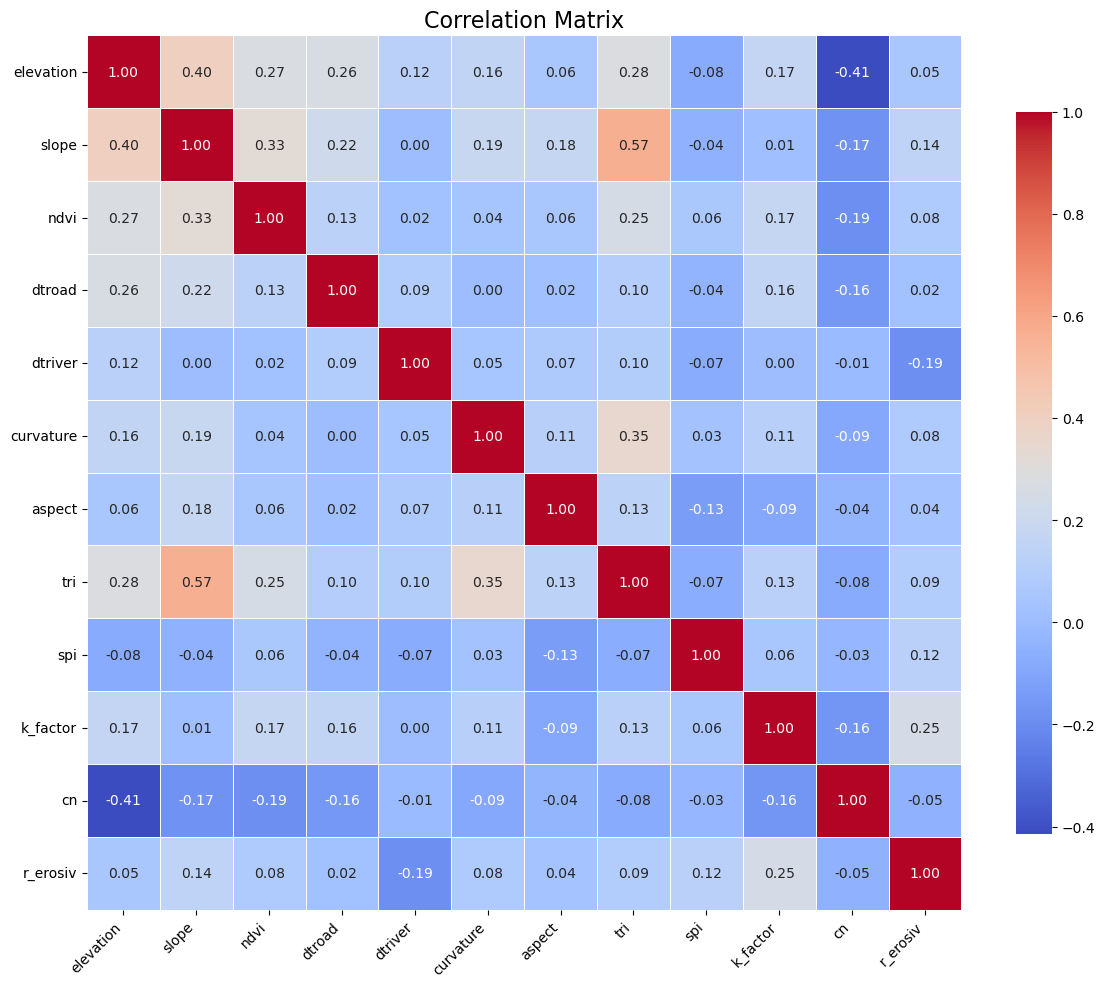

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corrMatrix = zero_labels.corr()

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Improved heatmap styling
sns.heatmap(
    corrMatrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# ----------------------------
# Save to Downloads folder
# ----------------------------
fig.savefig(save_path, dpi=1200, bbox_inches="tight")
plt.show()
plt.close(fig)

In [54]:
# Define features and target
X = df.drop(['OBJECTID', 'Label', 'geometry'], axis=1)  # Features (independent variables)
y = df['Label']   

In [55]:
# Identify categorical features (if any)
categorical_features = [i for i, col in enumerate(X.columns) if X[col].dtype == 'object']

In [56]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [57]:
# Ensure numeric type
X = X.astype(float)

# Replace NaN and infinite values with 0
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Check remaining issues
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

In [58]:
# CatBoost Classifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler

# Hyperparameter tuning (Grid Search)
param_grid = {
    'iterations': [200, 400],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5],
    'subsample': [0.6, 1.0],
    'border_count': [32, 64, 128]
}

cat = CatBoostClassifier(
    eval_metric='AUC',
    verbose=0,
    random_seed=42
)

grid_search = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_search.fit(X_train, y_train)
best_cat = grid_search.best_estimator_

# Make predictions
prediction_cat = best_cat.predict(X_test)

# Get probabilities for BOTH classes (0 and 1)
proba_cat = best_cat.predict_proba(X_test)  # shape: (n_samples, 2)

# Print best parameters for CatBoost
print(f"Best parameters for CatBoost: {grid_search.best_params_}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters for CatBoost: {'border_count': 128, 'depth': 4, 'iterations': 200, 'l2_leaf_reg': 1, 'learning_rate': 0.1, 'subsample': 0.6}


In [59]:
# --- Import required libraries ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# --- Standardize features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Initialize base SVM model ---
svm = SVC(probability=True)  # probability=True to enable predict_proba

# --- Define hyperparameter grid ---
param_grid = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10, 100],          # regularization parameter
    'gamma': ['scale', 'auto']       # kernel coefficient for 'rbf'
}

# --- Setup GridSearchCV with parallel processing and verbosity ---
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,    # Use all processors for speed
    verbose=2     # Show progress logs
)

# --- Fit GridSearchCV ---
grid_search.fit(X_train_scaled, y_train)

# --- Best estimator ---
best_svm = grid_search.best_estimator_

# --- Display best parameters ---
print(f"Best parameters for SVM: {grid_search.best_params_}")

# --- Predict on test data ---
prediction_svm = best_svm.predict(X_test_scaled)

# --- Get predicted probabilities for class 1 (positive class) ---
proba_svm = best_svm.predict_proba(X_test_scaled)[:, 1]


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters for SVM: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}


In [60]:
# Extra Trees Classifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler

# Hyperparameter tuning (Grid Search) 
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [False, True]
}

extra_trees = ExtraTreesClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=extra_trees,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_search.fit(X_train, y_train)
best_et = grid_search.best_estimator_

# Make predictions
prediction_et = best_et.predict(X_test)

# Get probabilities for BOTH classes (0 and 1)
proba_et = best_et.predict_proba(X_test)  # shape: (n_samples, 2)

# Print best parameters for Extra Trees
print(f"Best parameters for Extra Trees: {grid_search.best_params_}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best parameters for Extra Trees: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


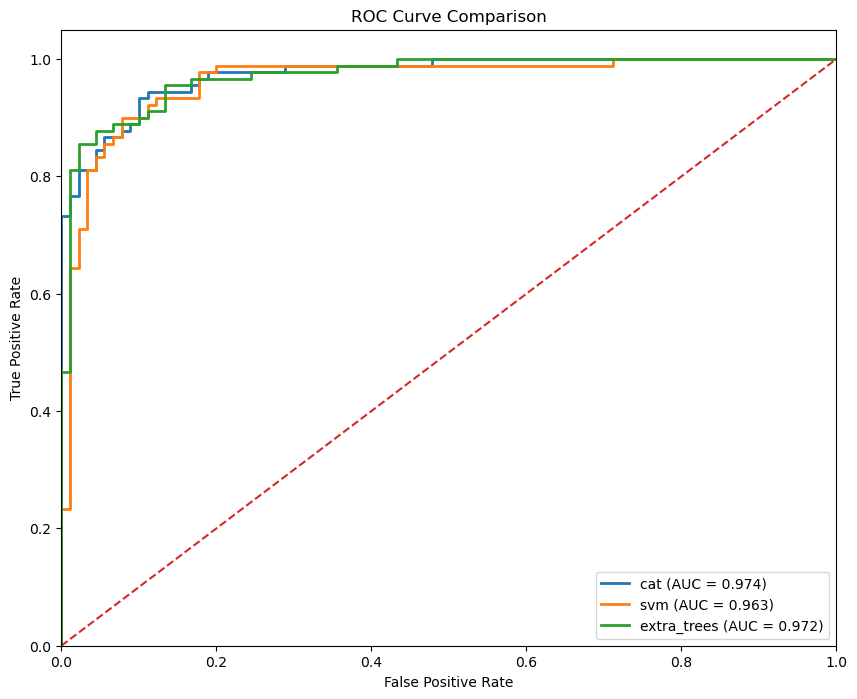

In [63]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

# Dictionary with model and scaled/unscaled test data as needed
models = {
    'cat': (best_cat, X_test),
    'svm': (best_svm, X_test_scaled),
    'extra_trees': (best_et, X_test)
}

plt.figure(figsize=(10, 8))

for name, (model, X_test_input) in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_input)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_input)
    else:
        raise ValueError(f"Model {name} does not have predict_proba or decision_function")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")

# Save figure; overwrites existing file automatically
plt.savefig(save_path, dpi=1200, bbox_inches="tight")

# Show once, then close to prevent duplicate display
plt.show()
plt.close()

In [64]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

target_names = ["Not Eroded", "Eroded"]

for name, (model, X_test_input) in models.items():
    print(f"=== {name} ===")
    # Predict class labels
    preds = model.predict(X_test_input)
    
    print(classification_report(y_test, preds, target_names=target_names))
    print("Kappa Score:", cohen_kappa_score(y_test, preds))
    cm = confusion_matrix(y_test, preds)
    print("Confusion Matrix:\n", cm)
    print("\n")

=== cat ===
              precision    recall  f1-score   support

  Not Eroded       0.92      0.90      0.91        90
      Eroded       0.90      0.92      0.91        90

    accuracy                           0.91       180
   macro avg       0.91      0.91      0.91       180
weighted avg       0.91      0.91      0.91       180

Kappa Score: 0.8222222222222222
Confusion Matrix:
 [[81  9]
 [ 7 83]]


=== svm ===
              precision    recall  f1-score   support

  Not Eroded       0.89      0.92      0.91        90
      Eroded       0.92      0.89      0.90        90

    accuracy                           0.91       180
   macro avg       0.91      0.91      0.91       180
weighted avg       0.91      0.91      0.91       180

Kappa Score: 0.8111111111111111
Confusion Matrix:
 [[83  7]
 [10 80]]


=== extra_trees ===
              precision    recall  f1-score   support

  Not Eroded       0.89      0.91      0.90        90
      Eroded       0.91      0.89      0.90      

Using features: ['elevation', 'slope', 'ndvi', 'dtroad', 'dtriver', 'curvature', 'aspect', 'tri', 'spi', 'k_factor', 'cn', 'r_erosiv']
Number of features: 12
CatBoost feature importance length: 12
Extra Trees feature importance length: 12


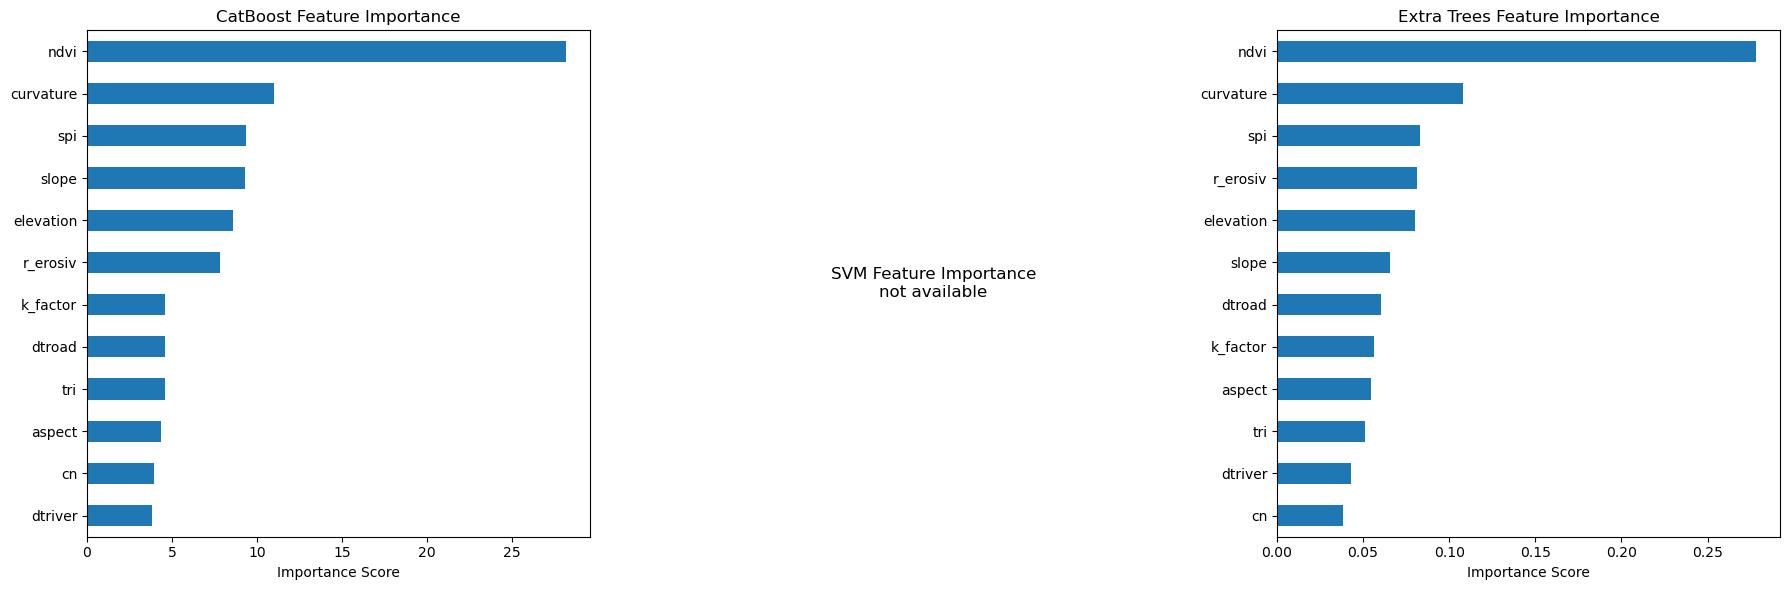

In [67]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import geopandas as gpd

# Load shapefile data
df = gpd.read_file("C:/Users/lnzab/OneDrive - Lund University/Skrivbordet/Paper 3/Data_ErosionNew/Data_ErosionNew.shp")

# Exclude columns not used as features
exclude_cols = ['OBJECTID', 'Label', 'geometry']

# Build features list
features_list = [col for col in df.columns if col not in exclude_cols]

print("Using features:", features_list)
print("Number of features:", len(features_list))
print("CatBoost feature importance length:", len(best_cat.feature_importances_))
print("Extra Trees feature importance length:", len(best_et.feature_importances_))

# Validate lengths
if len(features_list) == len(best_cat.feature_importances_) and len(features_list) == len(best_et.feature_importances_):
    importances_cat = pd.Series(best_cat.feature_importances_, index=features_list).sort_values(ascending=True)
    importances_et = pd.Series(best_et.feature_importances_, index=features_list).sort_values(ascending=True)
else:
    raise ValueError("Mismatch between feature list length and model feature importances length.")

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

importances_cat.plot.barh(ax=axes[0], title='CatBoost Feature Importance')
axes[0].set_xlabel('Importance Score')

axes[1].text(0.5, 0.5, "SVM Feature Importance\nnot available", ha='center', va='center', fontsize=12)
axes[1].axis('off')

importances_et.plot.barh(ax=axes[2], title='Extra Trees Feature Importance')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()

# ----------------------------
# Save to Downloads folder
# ----------------------------
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
os.makedirs(downloads_path, exist_ok=True)  # FIXED

output_file = os.path.join(downloads_path, 'feature_importance.jpg')

# Save (automatically overwrites existing file)
fig.savefig(output_file, format="jpg", dpi=1200, bbox_inches="tight")

plt.show()
plt.close(fig)


In [68]:
import shap
#import os
import matplotlib.pyplot as plt

# Initialize SHAP explainer for CatBoost
explainer_cat = shap.Explainer(best_cat)
shap_values_cat = explainer_cat(X_test)

# Prepare Downloads path
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
os.makedirs(downloads_path, exist_ok=True)

# ---------------------------
# 1️⃣ Waterfall Plot (Local Explanation)
# ---------------------------
shap.plots.waterfall(shap_values_cat[0], show=False)
fig = plt.gcf()
waterfall_path = os.path.join(downloads_path, 'shap_waterfall.jpg')
fig.savefig(waterfall_path, format='jpg', dpi=1200, bbox_inches='tight', pad_inches=0.2)
plt.close(fig)

# ---------------------------
# 2️⃣ Beeswarm Plot (Global Distribution)
# ---------------------------
shap.plots.beeswarm(shap_values_cat, show=False)
fig = plt.gcf()
beeswarm_path = os.path.join(downloads_path, 'shap_beeswarm.jpgg')
fig.savefig(beeswarm_path, format='jpg', dpi=1200, bbox_inches='tight', pad_inches=0.2)
plt.close(fig)

# ---------------------------
# 3️⃣ Global Feature Importance (Bar Plot)
# ---------------------------
shap.plots.bar(shap_values_cat, show=False)
fig = plt.gcf()
bar_path = os.path.join(downloads_path, 'shap_global_importance.jpg')
fig.savefig(bar_path, format='jpg', dpi=1200, bbox_inches='tight', pad_inches=0.2)
plt.close(fig)

In [69]:
# In order to map the water soil erosion susceptibility, we need to predict the water soil erosion susceptibility (probability between 0 and 1)
prediction_prob = best_cat.predict_proba(X_test)


In [70]:
# The probability of being not eroded and eroded for every location ( Their summation equals 1)
prediction_prob

array([[3.19828444e-02, 9.68017156e-01],
       [9.55764349e-01, 4.42356515e-02],
       [1.82846772e-03, 9.98171532e-01],
       [3.29774180e-02, 9.67022582e-01],
       [9.94424308e-01, 5.57569221e-03],
       [9.89293761e-01, 1.07062394e-02],
       [1.00359557e-02, 9.89964044e-01],
       [9.94431437e-01, 5.56856350e-03],
       [9.46158206e-01, 5.38417935e-02],
       [6.52480672e-01, 3.47519328e-01],
       [9.82450666e-01, 1.75493338e-02],
       [9.98972057e-01, 1.02794329e-03],
       [9.93801618e-01, 6.19838203e-03],
       [3.32525816e-04, 9.99667474e-01],
       [1.80863935e-01, 8.19136065e-01],
       [2.25335715e-03, 9.97746643e-01],
       [4.35590961e-03, 9.95644090e-01],
       [9.99528274e-01, 4.71725622e-04],
       [1.75744110e-01, 8.24255890e-01],
       [9.21068643e-01, 7.89313569e-02],
       [1.64721010e-02, 9.83527899e-01],
       [9.99735681e-01, 2.64318827e-04],
       [9.74209084e-01, 2.57909157e-02],
       [3.52581185e-01, 6.47418815e-01],
       [5.165946

In [71]:
import pickle
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
from geocube.api.core import make_geocube

In [72]:
# ---- Load your shapefile ----
shp_path = "C:/Users/lnzab/Documents/Paper 3/Study_AreaNew (1)/Study_AreaNew.shp"
gdf = gpd.read_file(shp_path)

In [73]:
# ---- save as pickle for future use
with open ('converted_data.pkl', 'wb') as f:
    pickle.dump(gdf, f)

In [74]:
# ---- PREPARE PREDICTOR VARIABLES ----
# Assume 'X' contains the column list for your predictors
X_columns = [
    'elevation', 'slope', 'ndvi', 'dtroad', 'dtriver', 
    'curvature', 'aspect', 'tri', 'spi', 'k_factor', 
    'cn', 'r_erosiv'
]

In [75]:
# Drop geometry for model input; ensure only existing cols used
X_hotspot0 = gdf.drop(columns=["geometry"]).copy()
X_hotspot0 = X_hotspot0[X_columns]
print(X_hotspot0.isnull().sum())

elevation    0
slope        0
ndvi         0
dtroad       0
dtriver      0
curvature    0
aspect       0
tri          0
spi          0
k_factor     0
cn           0
r_erosiv     0
dtype: int64


In [76]:
# Remove NA values from predictors & keep matching rows in gdf
non_na_idx = X_hotspot0.dropna().index
X_hotspot0 = X_hotspot0.loc[non_na_idx]
gdf = gdf.loc[non_na_idx].reset_index(drop=True)

In [77]:
# ---- EROSION SUSCEPTIBILITY PREDICTION ----
# Assume 'model' is a trained classifier, loaded elsewhere
# Example: with open('your_model.pkl','rb') as f: model = pickle.load(f)
prediction_prob = model.predict_proba(X_hotspot0)
# Get probability of positive/erosion class (adjust index as needed)
ls_hotspot0 = prediction_prob[:, 1]
gdf['SESM'] = ls_hotspot0

In [83]:
from geocube.api.core import make_geocube

# Assuming you already have your filtered predictor DataFrame (X_hotspot0) and gdf
# 1. Align all filtering steps:
non_na_idx = X_hotspot0.dropna().index
X_valid = X_hotspot0.loc[non_na_idx]
df = gdf.loc[non_na_idx].reset_index(drop=True)

# 2. Assign WSESM
df['SESM'] = model.predict_proba(X_valid)[:, 1]

# 3. Check
print(df.columns)   # Should list 'WSESM'

# 4. Rasterize
geo_grid = make_geocube(
    vector_data=df,
    measurements=['SESM'],
    resolution=(-20, 20)
)

Index(['OBJECTID', 'elevation', 'slope', 'ndvi', 'dtroad', 'dtriver',
       'curvature', 'aspect', 'tri', 'spi', 'k_factor', 'cn', 'r_erosiv',
       'geometry', 'SESM'],
      dtype='object')


In [84]:
geo_grid.SESM.plot()

In [85]:
geo_grid.SESM.rio.to_raster("SESM.tif")

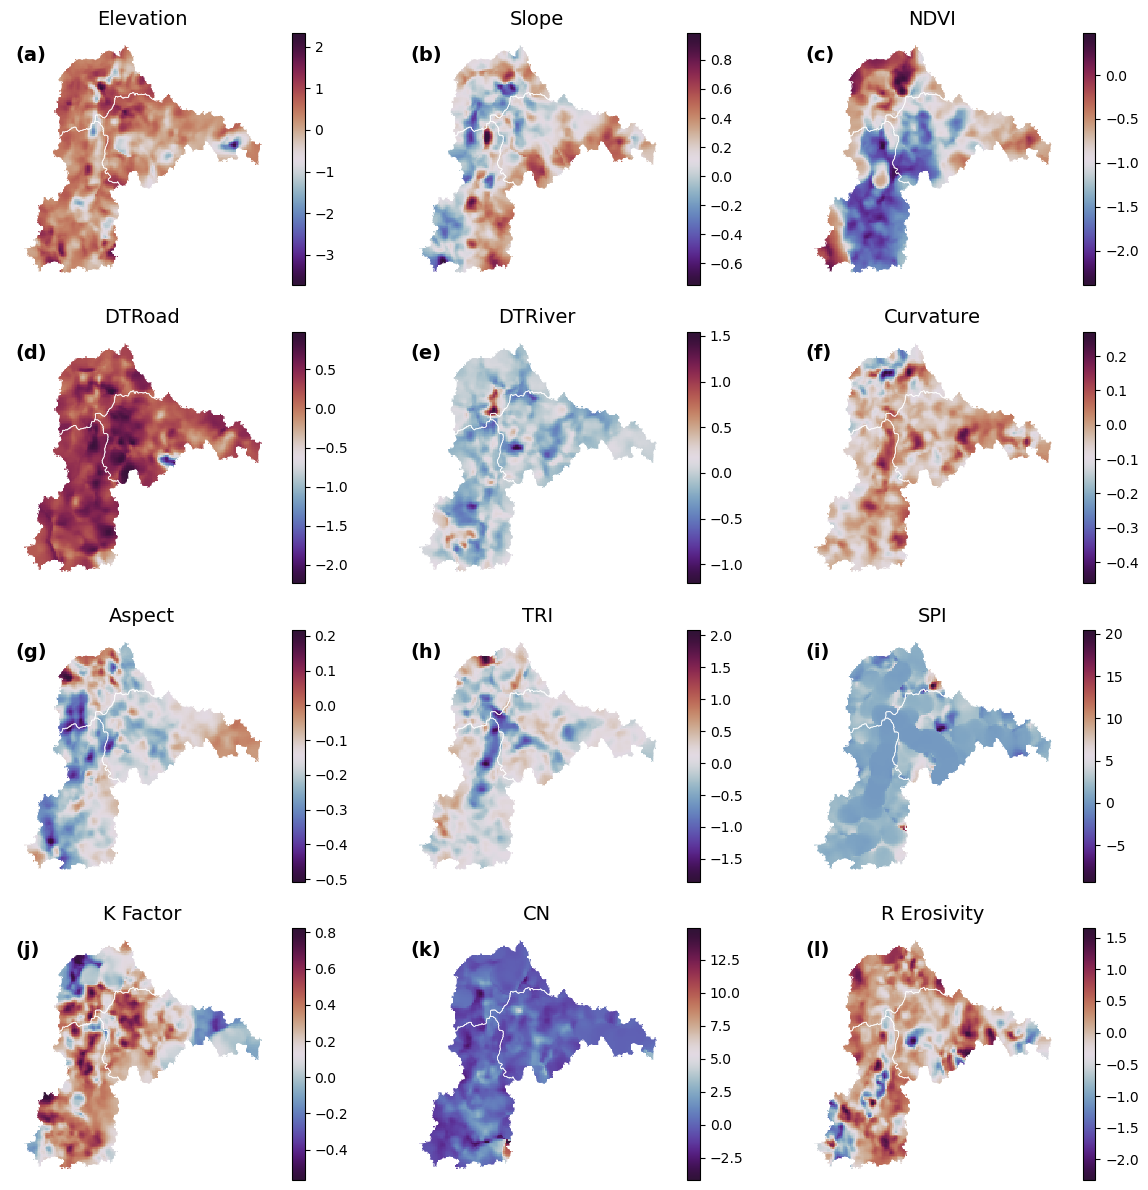

In [87]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import string

# Close previous figures to avoid accidental duplication
plt.close("all")

# Read shapefiles
df = gpd.read_file(
    "C:/Users/lnzab/Documents/Paper 3/Erosion_Nyab/Model results/GWR_probabilities.shp"
)

boundary = gpd.read_file(
    "C:/Users/lnzab/OneDrive - Lund University/Skrivbordet/Paper 3/Doc to submit/Erosion_points/Nyabarongo_m3.shp"
)

titles_mapping = {
    "beta_eleva": "Elevation",
    "beta_slope": "Slope",
    "beta_ndvi": "NDVI",
    "beta_dtroa": "DTRoad",
    "beta_dtriv": "DTRiver",
    "beta_curva": "Curvature",
    "beta_aspec": "Aspect",
    "beta_tri": "TRI",
    "beta_spi": "SPI",
    "beta_k_fac": "K Factor",
    "beta_cn": "CN",
    "beta_r_ero": "R Erosivity",
}

factors = [col for col in titles_mapping if col in df.columns]

num_cols = 3
num_rows = 4
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 12))
axes = axes.flatten()

letters = string.ascii_lowercase

for i, factor in enumerate(factors):
    ax = axes[i]

    df.plot(
        column=factor,
        ax=ax,
        legend=True,
        cmap="twilight_shifted"
    )

    # Plot only boundary overlay
    boundary.boundary.plot(ax=ax, color="white", linewidth=0.5)

    ax.set_title(titles_mapping[factor], fontsize=14)
    ax.set_axis_off()

    ax.text(
        0.02, 0.95,
        f"({letters[i]})",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left"
    )

# Hide unused axes, if any
for j in range(len(factors), len(axes)):
    axes[j].axis("off")

plt.tight_layout()

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
os.makedirs(downloads_path, exist_ok=True)
save_path = os.path.join(downloads_path, "GWR_Estimates.jpg")

fig.savefig(save_path, dpi=1200, bbox_inches="tight")

plt.show()
plt.close(fig)

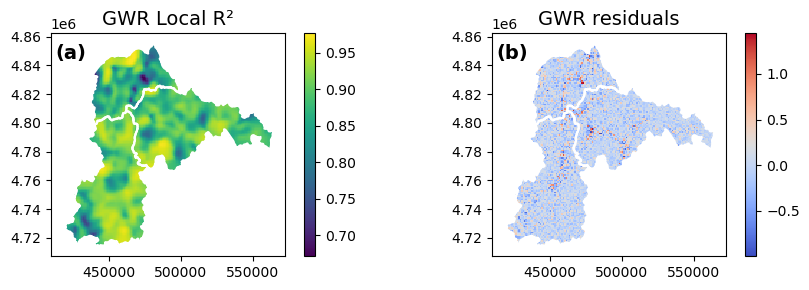

In [88]:
import matplotlib.pyplot as plt
import os

# Define mappings for titles and color palettes
titles_mapping = {
    "localR2": "GWR Local R²",
    "gwr_residu": "GWR residuals",
}

color_palettes = {
    "localR2": "viridis",
    "gwr_residu": "coolwarm",
}

factors = [col for col in titles_mapping.keys() if col in df.columns]

num_cols = 2
num_rows = 1

fig, axes = plt.subplots(num_rows, num_cols, figsize=(9, 3))
axes = axes.flatten()

subplot_labels = ["(a)", "(b)"]  # Required labels

for i, factor in enumerate(factors):
    ax = axes[i]
    cmap = color_palettes.get(factor, "viridis")

    df.plot(column=factor, ax=ax, legend=True, cmap=cmap)
    df_gwr.boundary.plot(ax=ax, color="white")

    ax.set_title(titles_mapping[factor], fontsize=14)

    # Add subplot label in upper-left corner
    ax.text(
        0.02, 0.95,
        subplot_labels[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='left'
    )

plt.tight_layout()

# Define Downloads path
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
os.makedirs(downloads_path, exist_ok=True)

save_path = os.path.join(downloads_path, "GWR_Estimates_1.jpg")

plt.savefig(save_path, dpi=1200, bbox_inches="tight")

plt.show()